In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [2]:
# =================================================================================
# 1. DATEN LADEN & BEREINIGEN
# =================================================================================

df = pd.read_csv("london_merged.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["Datum"] = df["timestamp"].dt.date
df["Zeit"]  = df["timestamp"].dt.time
df['month'] = df['timestamp'].dt.month
df["weekday"] = df["timestamp"].dt.dayofweek
df['hour'] = df['Zeit'].apply(lambda t: t.hour)

print (f"cnt: {df["cnt"].min():.1f} - {df["cnt"].max():.1f} | Mean: {df["cnt"].mean():.1f}")
print (f"timestamp: {df["timestamp"].min()} - {df["timestamp"].max()}")
print (f"shape: {df.shape[0]} Zeilen mit  {df.shape[1]} Spalten")

print(f"\nAnzahl fehlender Werte pro Spalte: {df.isnull().sum()}")

cnt: 0.0 - 7860.0 | Mean: 1143.1
timestamp: 2015-01-04 00:00:00 - 2017-01-03 23:00:00
shape: 17414 Zeilen mit  15 Spalten

Anzahl fehlender Werte pro Spalte: timestamp       0
cnt             0
t1              0
t2              0
hum             0
wind_speed      0
weather_code    0
is_holiday      0
is_weekend      0
season          0
Datum           0
Zeit            0
month           0
weekday         0
hour            0
dtype: int64


Die Datensätze enthalten keine leeren Felder.

Der Datensatz umfasst 17414 Zeilen mit 15 Spalten

| Feature        | Beschreibung                         |
|----------------|--------------------------------------|
| timestamp      | Zeitpunkt aus Datum und Stundenangabe |
| cnt            | Anzahl ausgeliehener Fahrräder       |
| t1             | Temperatur                           |
| t2             | Gefühlte Temperatur                  |
| hum            | Luftfeuchtigkeit                     |
| wind_speed     | Windgeschwindigkeit                  |
| weather_code   | Wetter-Code, siehe Fußnote*          |
| is_holiday     | Feiertag                             |
| is_weekend     | Wochenendne                          |
| season         | Jahreszeit                           |

*1 = Clear ; mostly clear but have some values with haze/fog/patches of fog/ fog in vicinity 2 = scattered clouds / few clouds 3 = Broken clouds 4 = Cloudy 7 = Rain/ light Rain shower/ Light rain 10 = rain with thunderstorm 26 = snowfall 94 = Freezing Fog


#### Tägliche Ausleihzahlen visualisieren

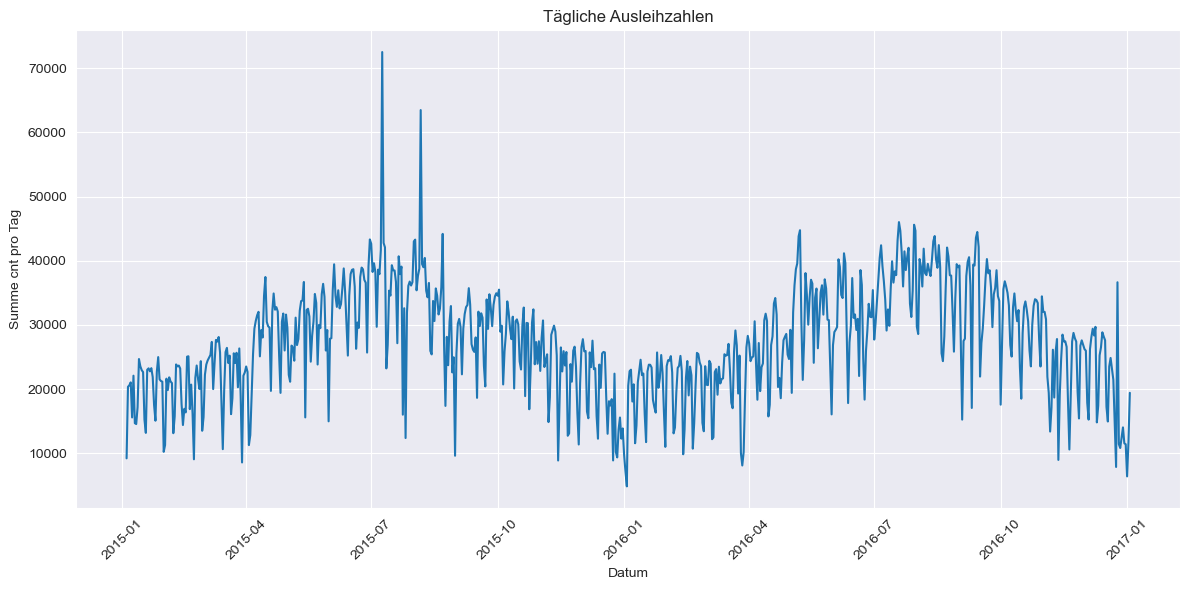

In [3]:
daily_cnt = df.groupby("Datum")["cnt"].sum().reset_index()
daily_cnt.rename(columns={"cnt": "cnt_sum"}, inplace=True)

# Datum als Datetime parsen (falls noch nicht)
daily_cnt["Datum"] = pd.to_datetime(daily_cnt["Datum"])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(daily_cnt["Datum"], daily_cnt["cnt_sum"])
plt.xlabel("Datum")
plt.ylabel("Summe cnt pro Tag")
plt.title("Tägliche Ausleihzahlen")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Wir stellen fest, dass es zwei deutliche Ausreißer gibt.

In [4]:
daily_cnt_sorted = daily_cnt.sort_values(by="cnt_sum", ascending=False)
print(daily_cnt_sorted.head())

         Datum  cnt_sum
186 2015-07-09    72504
214 2015-08-06    63468
562 2016-07-19    46021
573 2016-07-30    45608
490 2016-05-08    44758


### Streikbedingte Ausreißer eliminieren
An den Terminen 09.07.2015 und 06.08.2015 wurde die Tube in London bestreikt.
Diese nicht repräsentativen Daten werden entfernt.

In [5]:
# Streiktage entfernen (Ausreißer-Bereinigung)
strike_dates = ['2015-07-09', '2015-08-06']
rows_before = len(df)
df = df[~df['timestamp'].dt.strftime('%Y-%m-%d').isin(strike_dates)]
print(f"Streiktage entfernt: {rows_before - len(df)} Zeilen")
print(f"Finale Datenmenge: {len(df)} Zeilen")

Streiktage entfernt: 48 Zeilen
Finale Datenmenge: 17366 Zeilen


#### Tägliche Ausleihzahlen ohne Ausreißer

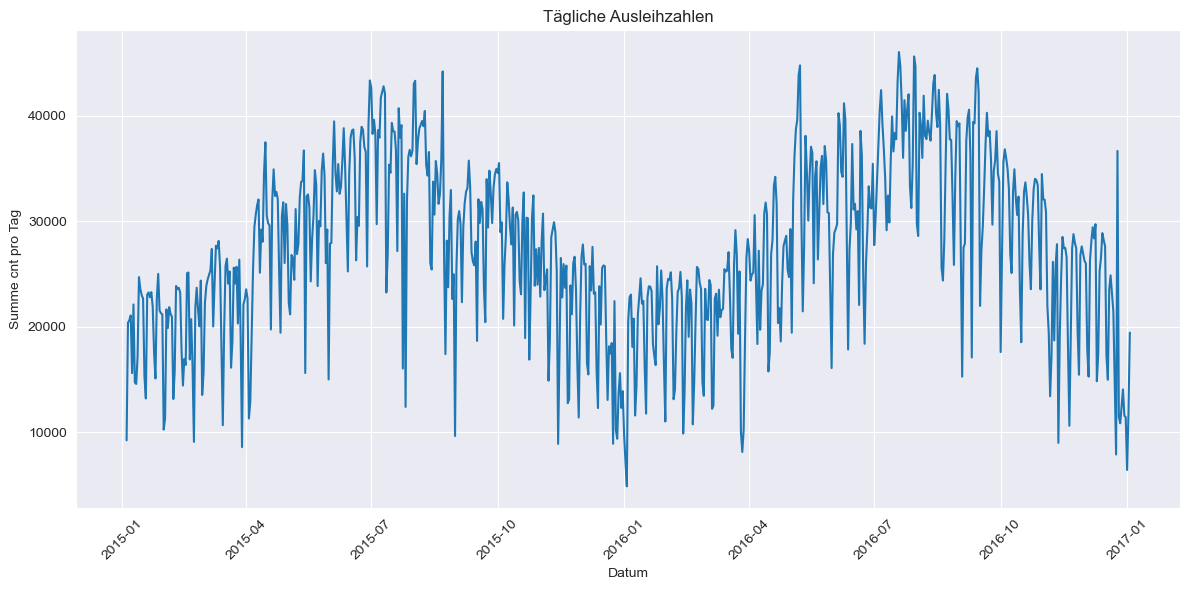

In [6]:
daily_cnt = df.groupby("Datum")["cnt"].sum().reset_index()
daily_cnt.rename(columns={"cnt": "cnt_sum"}, inplace=True)

# Datum als Datetime parsen (falls noch nicht)
daily_cnt["Datum"] = pd.to_datetime(daily_cnt["Datum"])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(daily_cnt["Datum"], daily_cnt["cnt_sum"])
plt.xlabel("Datum")
plt.ylabel("Summe cnt pro Tag")
plt.title("Tägliche Ausleihzahlen")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Täglicher Verlauf auf Basis aller Kalendertage innerhalb der Auswertungszeit.

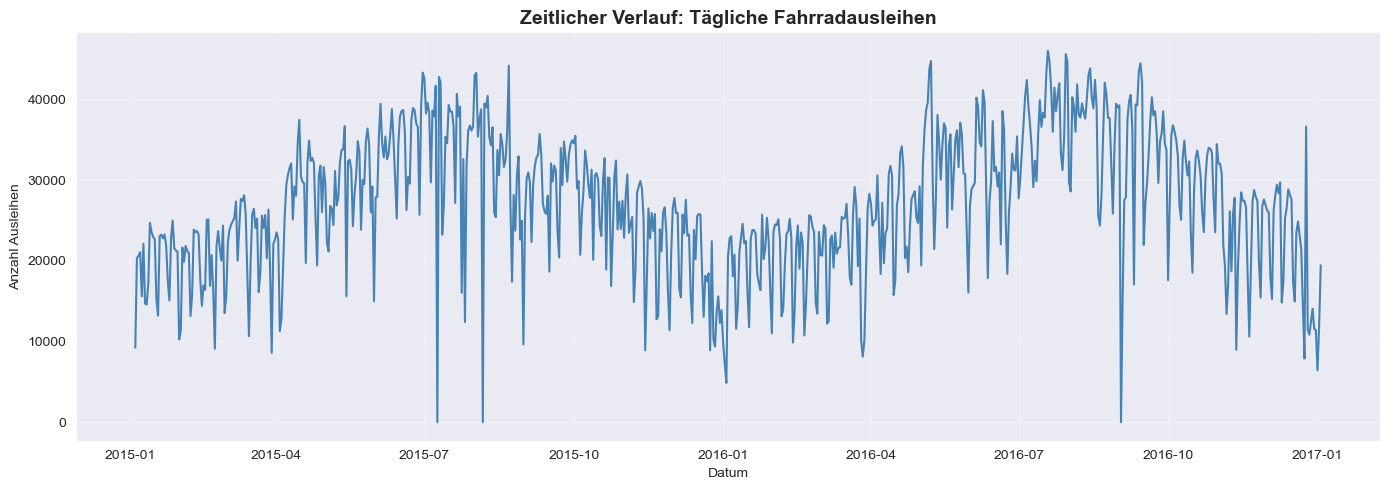

Plot 2: Zeitreihe gespeichert


In [7]:
# 3.2 Zeitlicher Verlauf (Tägliche Aggregation)
plt.figure(figsize=(14, 5))
daily_cnt = df.set_index('timestamp')['cnt'].resample('D').sum()
plt.plot(daily_cnt, color='steelblue', linewidth=1.5)
plt.title('Zeitlicher Verlauf: Tägliche Fahrradausleihen', fontsize=14, fontweight='bold')
plt.xlabel('Datum')
plt.ylabel('Anzahl Ausleihen')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('02_time_series.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 2: Zeitreihe gespeichert")

Die eliminierten Termine 09.07.2015 und 06.08.2015 sind in der Darstellung wiederzuerkennen. Zudem fällt auf, dass es keine Daten zwischen dem 01.09.2016 23:00 Uhr und dem 03.11.2016 11:00 Uhr gibt.

### Betrachteng der zeitlichen Verläufe

#### Summe Ausleihvorgänge je Monat

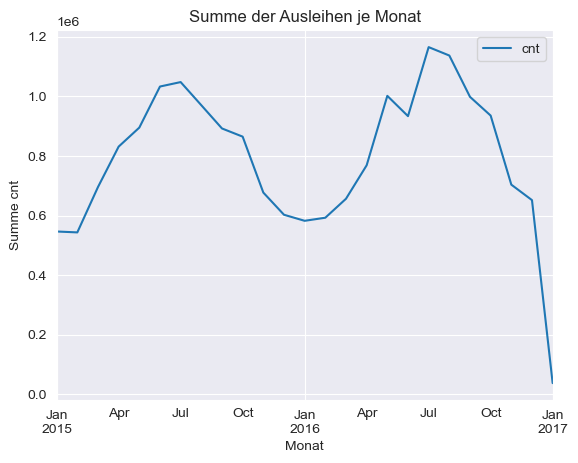

In [8]:
# Anzahl je Monat
# Monatliche Summe von cnt berechnen
monthly_cnt = df.groupby(df["timestamp"].dt.to_period("M"))["cnt"].sum().reset_index()
monthly_cnt.plot(x="timestamp", y="cnt", kind="line")
plt.xlabel("Monat")
plt.ylabel("Summe cnt")
plt.title("Summe der Ausleihen je Monat")
plt.grid(True)
plt.show()

Wie zu erwarten sind die Hochzeiten in den Sommermonaten und die Tiefststände im Januar zu erkennen.

#### Verteilung auf Wochentage nach Werktagen/Wochenenden/Feiertagen

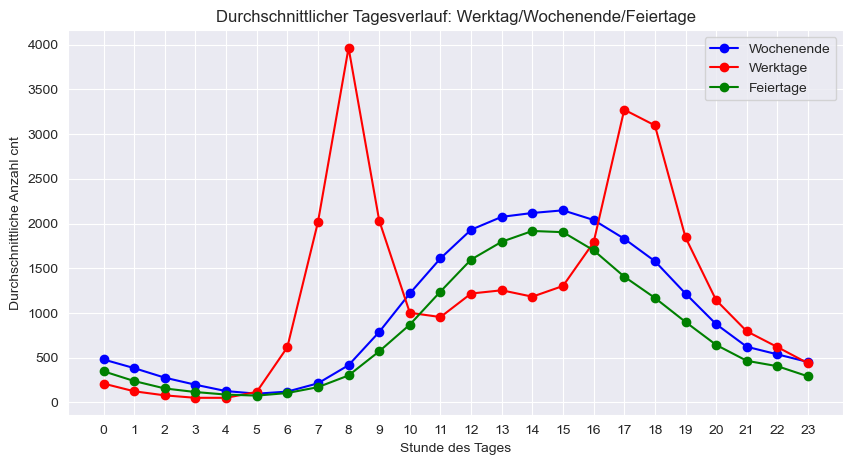

In [9]:
#Wochnend-Daten extrahieren
weekend_data = df[df["is_weekend"] == 1]
# Durchschnittliche cnt je Stunde (nur Wochenende)
mean_cnt_per_hour_weekend = weekend_data.groupby("hour")["cnt"].mean()

#Werktags-Daten extrahieren
week_data = df[(df["is_holiday"] == 0) & (df["is_weekend"] == 0)]
mean_cnt_per_hour_week = week_data.groupby("hour")["cnt"].mean()

#Feiertags-Daten extrahieren
holiday_data = df[(df["is_holiday"] == 1) ]
mean_cnt_per_hour_holiday = holiday_data.groupby("hour")["cnt"].mean()

# Plot
plt.figure(figsize=(10,5))
mean_cnt_per_hour_weekend.plot(marker='o', color='blue', label='Wochenende')
mean_cnt_per_hour_week.plot(marker='o', color='red', label='Werktage')
mean_cnt_per_hour_holiday.plot(marker='o', color='green',label='Feiertage')
plt.xlabel('Stunde des Tages')
plt.ylabel('Durchschnittliche Anzahl cnt')
plt.title('Durchschnittlicher Tagesverlauf: Werktag/Wochenende/Feiertage')
plt.xticks(range(0,24))
plt.grid(True)
plt.legend()
plt.show()

An Werktagen sind Häufungen zu den Pendel-Zeiten 08:00 und 17:00 Uhr zu erkennen. An Nicht-Werktagen verteilt sich die Stärkste Zeit über die Nachmittagsstunden.

### Verhältnis zwischen den Spalten

#### Korrelationsmatrix


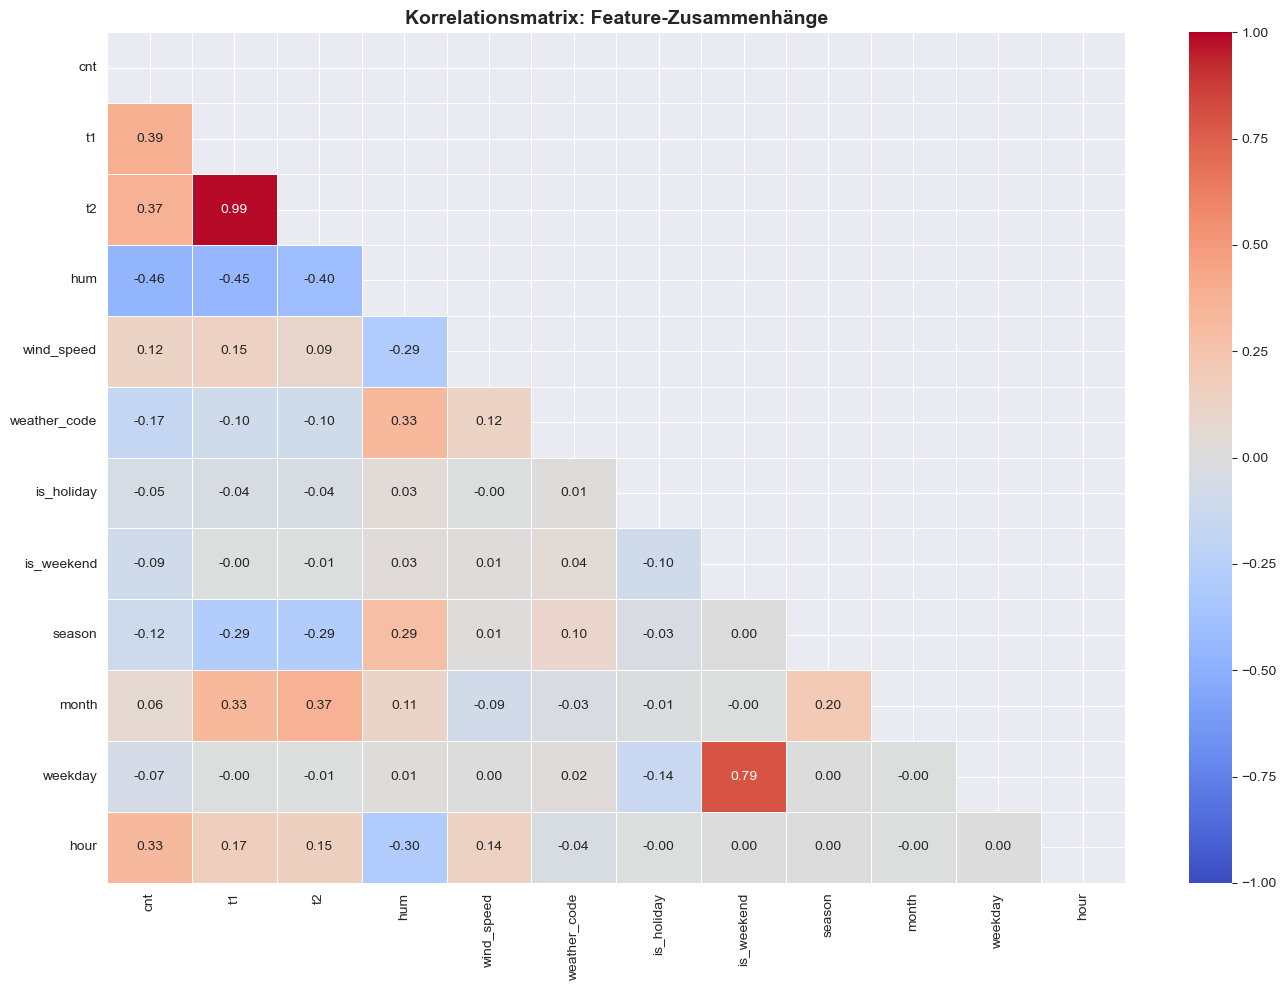

Plot 1: Korrelationsmatrix gespeichert


In [10]:

# Korrelationsmatrix
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include=[np.number])
mask = np.triu(np.ones_like(numeric_cols.corr(), dtype=bool))
sns.heatmap(numeric_cols.corr(), mask=mask, annot=True, cmap='coolwarm',
            fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Korrelationsmatrix: Feature-Zusammenhänge', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 1: Korrelationsmatrix gespeichert")

Plot 2: Zeitreihe gespeichert


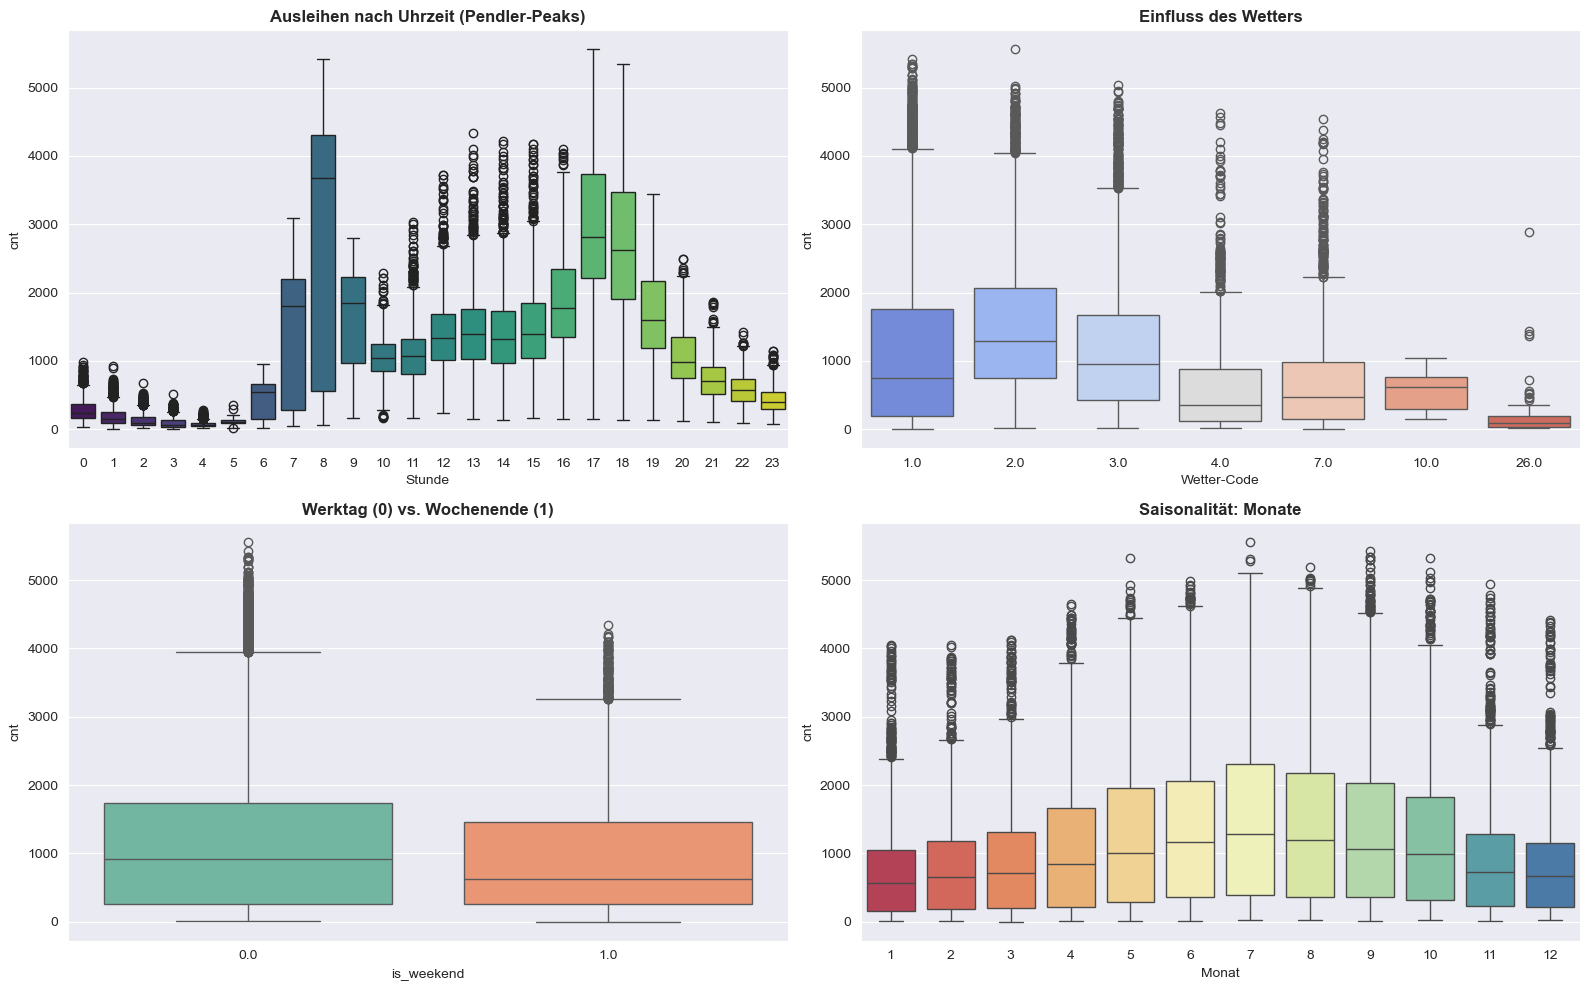

Plot 3: EDA Multi-Panel gespeichert


In [11]:
print("Plot 2: Zeitreihe gespeichert")


# 3.3 Multi-Panel: Uhrzeit, Wetter, Wochenende
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Uhrzeit (Pendler-Muster)
sns.boxplot(data=df, x='hour', y='cnt', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Ausleihen nach Uhrzeit (Pendler-Peaks)', fontweight='bold')
axes[0,0].set_xlabel('Stunde')

# Panel 2: Wetter
sns.boxplot(data=df, x='weather_code', y='cnt', ax=axes[0,1], palette='coolwarm')
axes[0,1].set_title('Einfluss des Wetters', fontweight='bold')
axes[0,1].set_xlabel('Wetter-Code')

# Panel 3: Werktag vs. Wochenende
sns.boxplot(data=df, x='is_weekend', y='cnt', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Werktag (0) vs. Wochenende (1)', fontweight='bold')

# Panel 4: Monatliche Variation
sns.boxplot(data=df, x='month', y='cnt', ax=axes[1,1], palette='Spectral')
axes[1,1].set_title('Saisonalität: Monate', fontweight='bold')
axes[1,1].set_xlabel('Monat')

plt.tight_layout()
plt.savefig('03_eda_panels.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 3: EDA Multi-Panel gespeichert")


### Beziehungen zwischen den Fetures visualisieren


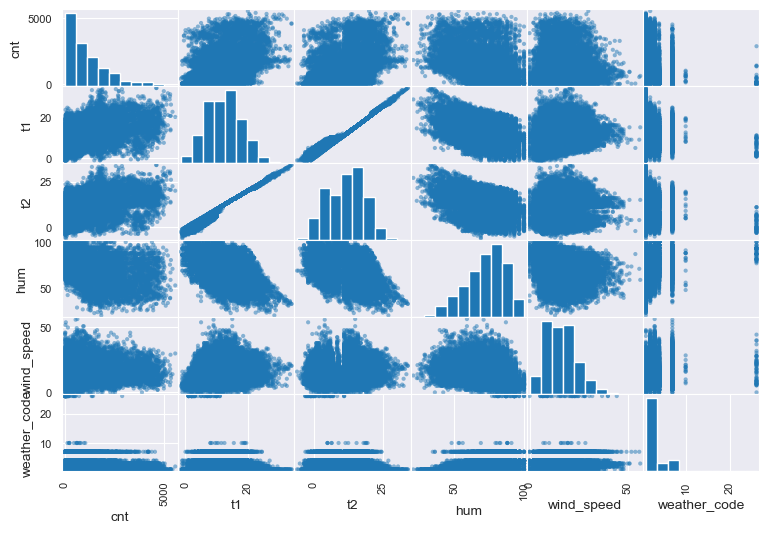

In [12]:
attributes = ['cnt', 't1', 't2', 'hum', 'wind_speed', 'weather_code' ]
scatter_matrix(df[attributes], figsize=(9, 6))
plt.show()

### Verteilung der Daten

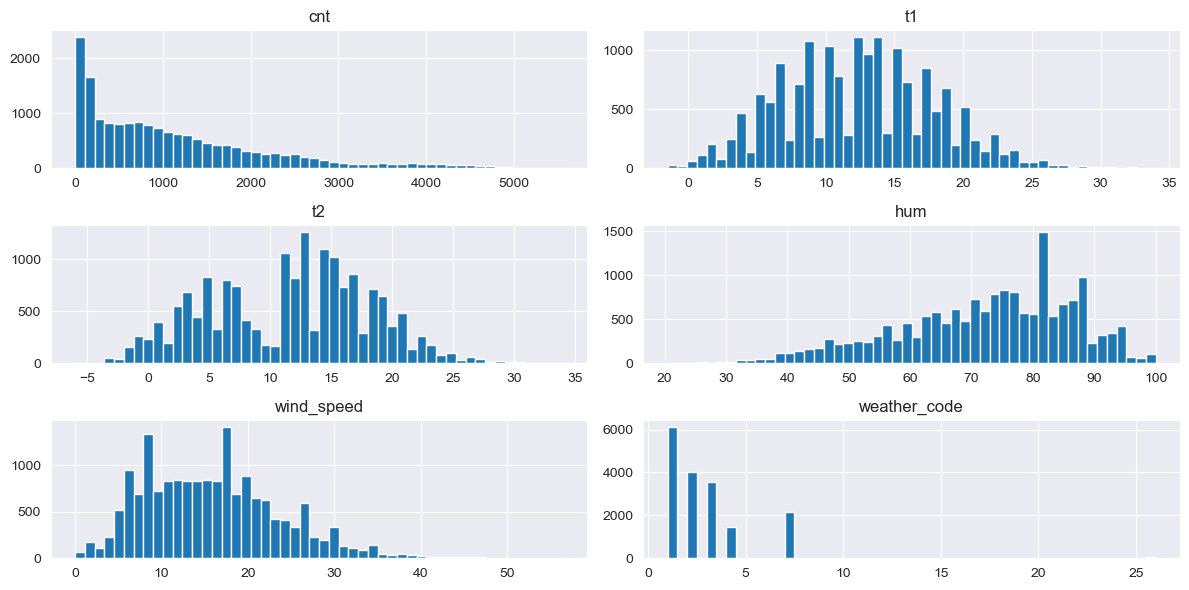

In [13]:
num_cols = ['cnt', 't1', 't2', 'hum', 'wind_speed', 'weather_code']
df[num_cols].hist(bins=50, figsize=(12, 6))
plt.tight_layout()
plt.show()